In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import (EarlyStopping,
                                         ReduceLROnPlateau)
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error,
                              mean_absolute_error,
                              r2_score)
import joblib
import gc
import warnings
warnings.filterwarnings('ignore')

meter_map = {
    0: 'Electricity',
    1: 'Chilled Water',
    2: 'Steam',
    3: 'Hot Water'
}

print("✅ Libraries imported!")
print(f"   TensorFlow : {tf.__version__}")

✅ Libraries imported!
   TensorFlow : 2.20.0


In [ ]:
cols_needed = [
    'building_id', 'meter', 'timestamp', 'meter_reading',
    'meter_reading_log', 'site_id', 'primary_use',
    'air_temperature', 'dew_temperature', 'wind_speed',
    'sea_level_pressure', 'hour', 'month', 'weekday',
    'is_weekend', 'square_feet', 'CDD', 'HDD'
]

df = pd.read_parquet(
    '/content/drive/MyDrive/hvac_project/eda_final_v3.parquet',
    columns=cols_needed
)

# Convert to float32 immediately
float_cols = ['air_temperature', 'dew_temperature',
              'wind_speed', 'sea_level_pressure',
              'meter_reading', 'meter_reading_log',
              'CDD', 'HDD']
for col in float_cols:
    df[col] = df[col].astype(np.float32)

print(f"✅ Data loaded!")
print(f"   Shape        : {df.shape}")
print(f"   Missing vals : {df.isnull().sum().sum()}")
print(f"   Memory usage : "
      f"{df.memory_usage(deep=True).sum()/1024**3:.2f} GB")

print(f"\nRows per meter:")
for meter_id, meter_name in meter_map.items():
    count = len(df[df['meter'] == meter_id])
    print(f"  {meter_name:15} : {count:,}")

✅ Data loaded!
   Shape        : (4316560, 18)
   Missing vals : 3138
   Memory usage : 0.62 GB

Rows per meter:
  Electricity     : 1,731,963
  Chilled Water   : 1,207,968
  Steam           : 865,568
  Hot Water       : 511,061


In [ ]:
weather_cols = ['air_temperature', 'dew_temperature',
                'wind_speed', 'sea_level_pressure',
                'CDD', 'HDD']

df = df.sort_values(
    ['building_id', 'meter', 'timestamp']
).reset_index(drop=True)

df[weather_cols] = df.groupby('site_id')[weather_cols]\
                     .transform(lambda x: x.ffill().bfill())

print(f"✅ Missing values handled!")
print(f"   Remaining : {df.isnull().sum().sum()}")

✅ Missing values handled!
   Remaining : 0


In [ ]:
def get_season(month):
    if month in [12, 1, 2]:   return 0  # Winter
    elif month in [3, 4, 5]:  return 1  # Spring
    elif month in [6, 7, 8]:  return 2  # Summer
    else:                      return 3  # Fall

df['season']           = df['month'].apply(get_season)
df['is_business_hour'] = df['hour'].between(9, 17).astype(int)
df['log_square_feet']  = np.log1p(df['square_feet'])
df['temp_dew_diff']    = (df['air_temperature'] -
                           df['dew_temperature']).astype(np.float32)

print("✅ Features engineered!")
print(f"   Added: season, is_business_hour, "
      f"log_square_feet, temp_dew_diff")

✅ Features engineered!
   Added: season, is_business_hour, log_square_feet, temp_dew_diff


In [ ]:
lstm_features = [
    # Time features
    'hour', 'month', 'weekday', 'is_weekend',
    'season', 'is_business_hour',
    # Weather features
    'air_temperature', 'dew_temperature',
    'wind_speed', 'sea_level_pressure',
    'CDD', 'HDD', 'temp_dew_diff',
    # Building features
    'log_square_feet',
    # Consumption history — key fix
    'meter_reading_log'
]

lstm_target = 'meter_reading_log'

print(f"✅ Features defined!")
print(f"   Total features : {len(lstm_features)}")
print(f"   Features       : {lstm_features}")

✅ Features defined!
   Total features : 15
   Features       : ['hour', 'month', 'weekday', 'is_weekend', 'season', 'is_business_hour', 'air_temperature', 'dew_temperature', 'wind_speed', 'sea_level_pressure', 'CDD', 'HDD', 'temp_dew_diff', 'log_square_feet', 'meter_reading_log']


In [ ]:
print("--- Feature Verification ---")

missing_cols = [c for c in lstm_features
                if c not in df.columns]
if missing_cols:
    print(f"⚠️ Missing columns: {missing_cols}")
else:
    print("✅ All feature columns present!")

# NaN check
nan_count = df[lstm_features].isnull().sum().sum()
print(f"\nNaN in features    : {nan_count}")

# Infinity check
num_df    = df[lstm_features].select_dtypes(include=[np.number])
inf_count = np.isinf(num_df.values).sum()
print(f"Infinity in features: {inf_count}")

if inf_count > 0:
    df[lstm_features] = df[lstm_features].replace(
        [np.inf, -np.inf], np.nan)
    df = df.dropna(subset=lstm_features)
    print(f"✅ Fixed! New shape: {df.shape}")
else:
    print("✅ No issues — ready for sequences!")

# Buildings per meter
print(f"\nBuildings per meter:")
for meter_id, meter_name in meter_map.items():
    n = df[df['meter']==meter_id]['building_id'].nunique()
    print(f"  {meter_name:15} : {n} buildings")

--- Feature Verification ---
✅ All feature columns present!

NaN in features    : 0
Infinity in features: 0
✅ No issues — ready for sequences!

Buildings per meter:
  Electricity     : 216 buildings
  Chilled Water   : 151 buildings
  Steam           : 112 buildings
  Hot Water       : 59 buildings


In [ ]:
def select_representative_buildings(df_meter,
                                     max_buildings=80):
    building_types  = df_meter.groupby('building_id')\
                               ['primary_use'].first()
    building_counts = df_meter.groupby('building_id').size()
    unique_types    = building_types.unique()

    selected  = []
    per_type  = max(1, max_buildings // len(unique_types))

    for btype in unique_types:
        type_buildings = building_types[
            building_types == btype
        ].index
        type_counts = building_counts[type_buildings]\
                          .sort_values(ascending=False)
        selected.extend(
            type_counts.head(per_type).index.tolist()
        )

    # Fill remaining slots with top buildings by completeness
    if len(selected) < max_buildings:
        remaining = building_counts.drop(
            index=selected, errors='ignore'
        ).nlargest(max_buildings - len(selected)).index
        selected.extend(remaining.tolist())

    final = selected[:max_buildings]
    print(f"   Selected {len(final)} buildings "
          f"across {len(unique_types)} building types")
    return final

print("✅ Building selection function defined!")

✅ Building selection function defined!


In [ ]:
def create_sequences_stratified(df_meter,
                                  feature_cols,
                                  target_col,
                                  window=24,
                                  train_ratio=0.70):
    X_train_all, y_train_all = [], []
    X_test_all,  y_test_all  = [], []
    skipped                  = 0

    for building_id, group in df_meter.groupby('building_id'):
        group = group.sort_values('timestamp')

        # Remove zero readings
        group = group[group['meter_reading'] > 0]

        # Drop NaN
        group = group.dropna(
            subset=feature_cols + [target_col])

        if len(group) < window + 1:
            skipped += 1
            continue

        X_vals = group[feature_cols].values.astype(np.float32)
        y_vals = group[target_col].values.astype(np.float32)
        months = group['month'].values

        # Skip if NaN or infinity present
        if (np.isnan(X_vals).any() or
            np.isnan(y_vals).any() or
            np.isinf(X_vals).any()):
            skipped += 1
            continue

        # Create all sequences for this building
        X_bld, y_bld, m_bld = [], [], []
        for i in range(len(X_vals) - window):
            X_bld.append(X_vals[i:i+window])
            y_bld.append(y_vals[i+window])
            m_bld.append(months[i+window])

        X_bld = np.array(X_bld, dtype=np.float32)
        y_bld = np.array(y_bld, dtype=np.float32)
        m_bld = np.array(m_bld)

        # Stratified split per month
        for month in range(1, 13):
            mask    = m_bld == month
            X_month = X_bld[mask]
            y_month = y_bld[mask]

            if len(X_month) < 2:
                X_train_all.extend(X_month)
                y_train_all.extend(y_month)
                continue

            split = int(len(X_month) * train_ratio)
            X_train_all.extend(X_month[:split])
            y_train_all.extend(y_month[:split])
            X_test_all.extend(X_month[split:])
            y_test_all.extend(y_month[split:])

    if skipped > 0:
        print(f"   Skipped {skipped} buildings "
              f"(insufficient data)")

    return (
        np.array(X_train_all, dtype=np.float32),
        np.array(y_train_all, dtype=np.float32),
        np.array(X_test_all,  dtype=np.float32),
        np.array(y_test_all,  dtype=np.float32)
    )

print("✅ Stratified sequence creation function defined!")

✅ Stratified sequence creation function defined!


In [ ]:
def make_dataset(X, y, batch_size=512, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=10000, seed=42)
    dataset = dataset.batch(batch_size)\
                     .prefetch(tf.data.AUTOTUNE)
    return dataset


def build_lstm(timesteps, n_features):
    model = Sequential([
        Input(shape=(timesteps, n_features)),
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

print("✅ Dataset and model builder defined!")

✅ Dataset and model builder defined!


In [ ]:
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

def train_lstm(df, meter_id, meter_name,
               window=24, epochs=20,
               batch_size=512, max_buildings=80):

    print(f"\n{'='*55}")
    print(f"LSTM — {meter_name.upper()}")
    print(f"{'='*55}")

    df_meter = df[df['meter'] == meter_id].copy()

    if len(df_meter) == 0:
        print("No data — skipping")
        return None

    # Select representative buildings
    print("Selecting buildings...")
    selected = select_representative_buildings(
        df_meter, max_buildings
    )
    df_meter = df_meter[
        df_meter['building_id'].isin(selected)
    ].copy()

    print(f"Total rows : {len(df_meter):,}")
    print(f"Buildings  : {df_meter['building_id'].nunique()}")
    print(f"Types      : "
          f"{df_meter['primary_use'].nunique()} building types")

    # Scale features
    feature_scaler  = MinMaxScaler()
    scaled_features = feature_scaler.fit_transform(
        df_meter[lstm_features]
    ).astype(np.float32)
    df_meter                = df_meter.copy()
    df_meter[lstm_features] = scaled_features

    # Create stratified sequences
    print("Creating stratified sequences...")
    X_train, y_train_raw, X_test, y_test_raw = \
        create_sequences_stratified(
            df_meter, lstm_features,
            lstm_target, window
        )

    if len(X_train) == 0:
        print("Not enough sequences — skipping")
        return None

    print(f"\nTrain sequences : {len(X_train):,}")
    print(f"Test sequences  : {len(X_test):,}")
    print(f"RAM for sequences: "
          f"{(X_train.nbytes + X_test.nbytes)/1024**3:.2f} GB")

    # Scale target on TRAIN ONLY — no leakage
    target_scaler  = MinMaxScaler()
    y_train_scaled = target_scaler.fit_transform(
        y_train_raw.reshape(-1, 1)
    ).flatten().astype(np.float32)

    # Validation split from train
    val_size     = int(len(X_train) * 0.1)
    X_val        = X_train[-val_size:]
    y_val_scaled = y_train_scaled[-val_size:]
    X_tr         = X_train[:-val_size]
    y_tr_scaled  = y_train_scaled[:-val_size]

    # Create tf.data datasets
    train_ds = make_dataset(X_tr, y_tr_scaled,
                             batch_size, shuffle=True)
    val_ds   = make_dataset(X_val, y_val_scaled,
                             batch_size, shuffle=False)

    # Free arrays after dataset creation
    del X_tr, y_tr_scaled, X_val, y_val_scaled
    del X_train, y_train_scaled
    gc.collect()
    print("✅ RAM freed after dataset creation!")

    # Build model
    model = build_lstm(window, len(lstm_features))
    model.summary()

    # Callbacks
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )

    # Train
    print("\nTraining...")
    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    del train_ds, val_ds
    gc.collect()

    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'],
                 label='Train', color='steelblue')
    axes[0].plot(history.history['val_loss'],
                 label='Val', color='tomato')
    axes[0].set_title(f'{meter_name} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()
    axes[1].plot(history.history['mae'],
                 label='Train', color='steelblue')
    axes[1].plot(history.history['val_mae'],
                 label='Val', color='tomato')
    axes[1].set_title(f'{meter_name} — MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    plt.suptitle(f'LSTM Training — {meter_name}',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

    # =============================================
    # EVALUATION — CORRECTLY ON ACTUAL SCALE
    # =============================================
    print("\nGenerating predictions...")
    test_ds = tf.data.Dataset\
                .from_tensor_slices(X_test)\
                .batch(batch_size)
    y_pred_scaled = model.predict(test_ds).flatten()

    # Inverse scale predictions back to log scale
    y_pred_log = target_scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).flatten()

    # y_test_raw is already in original log scale
    # DO NOT inverse transform — just use directly
    y_test_log = y_test_raw

    # Convert log to actual meter reading scale
    y_pred_actual = np.clip(np.expm1(y_pred_log), 0, None)
    y_test_actual = np.expm1(y_test_log)

    # Verify scale is correct
    print(f"\n   Scale verification:")
    print(f"   y_test_actual range : "
          f"{y_test_actual.min():.2f} to "
          f"{y_test_actual.max():.2f}")
    print(f"   y_pred_actual range : "
          f"{y_pred_actual.min():.2f} to "
          f"{y_pred_actual.max():.2f}")

    if y_test_actual.max() < 10:
        print("   ⚠️ WARNING: Still on log scale!")
    else:
        print("   ✅ Confirmed on actual scale!")

    # Metrics on actual scale
    rmse  = np.sqrt(mean_squared_error(
        y_test_actual, y_pred_actual))
    mae   = mean_absolute_error(
        y_test_actual, y_pred_actual)
    r2    = r2_score(
        y_test_actual, y_pred_actual)

    # RMSLE on log scale — designed for this
    rmsle = np.sqrt(mean_squared_error(
        y_test_log, y_pred_log))

    # Tolerance accuracy
    pct_error = np.abs(
        (y_test_actual - y_pred_actual) /
        (y_test_actual + 1)
    ) * 100

    print(f"\n{'='*40}")
    print(f"LSTM — {meter_name} RESULTS")
    print(f"(RMSE and MAE on actual meter reading scale)")
    print(f"{'='*40}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"R²    : {r2:.4f}")
    print(f"RMSLE : {rmsle:.4f}")
    for t in [10, 20, 30]:
        acc = (pct_error <= t).mean() * 100
        print(f"Within {t}% : {acc:.2f}%")

    # Actual vs Predicted plot
    n_sample   = min(5000, len(y_test_actual))
    sample_idx = np.random.choice(
        len(y_test_actual), n_sample, replace=False)
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test_actual[sample_idx],
                y_pred_actual[sample_idx],
                alpha=0.2, s=2, color='mediumpurple')
    plt.plot([0, y_test_actual.max()],
             [0, y_test_actual.max()],
             'r-', linewidth=1, label='Perfect')
    plt.title(f'LSTM — {meter_name}\n'
              f'R²={r2:.4f} | RMSE={rmse:.2f} '
              f'(actual scale)')
    plt.xlabel('Actual Meter Reading')
    plt.ylabel('Predicted Meter Reading')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Save model and scalers
    meter_slug = meter_name.lower().replace(' ', '_')
    model.save(
        f'/content/drive/MyDrive/hvac_project/'
        f'lstm_v5_{meter_slug}.keras')
    joblib.dump(feature_scaler,
        f'/content/drive/MyDrive/hvac_project/'
        f'lstm_v5_fscaler_{meter_slug}.pkl')
    joblib.dump(target_scaler,
        f'/content/drive/MyDrive/hvac_project/'
        f'lstm_v5_tscaler_{meter_slug}.pkl')
    print(f"\n✅ {meter_name} LSTM saved!")

    # Cleanup
    del X_test, y_test_raw
    del y_pred_scaled, y_pred_log
    del y_pred_actual, y_test_actual
    gc.collect()

    return (rmse, mae, r2, rmsle)

print("✅ LSTM training function defined!")
print("   Evaluation correctly on actual scale")
print("   Random seeds set for reproducibility")

✅ LSTM training function defined!
   Evaluation correctly on actual scale
   Random seeds set for reproducibility



LSTM — ELECTRICITY
Selecting buildings...
   Selected 80 buildings across 11 building types
Total rows : 694,406
Buildings  : 80
Types      : 11 building types
Creating stratified sequences...

Train sequences : 39,373
Test sequences  : 16,935
RAM for sequences: 0.08 GB
✅ RAM freed after dataset creation!


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 24, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,249 (489.25 KB)

 Trainable params: 125,249 (489.25 KB)

 Non-trainable params: 0 (0.00 B)


Training...
Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0193 - mae: 0.0980 - val_loss: 0.0115 - val_mae: 0.0773 - learning_rate: 0.0010
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0040 - mae: 0.0492 - val_loss: 0.0112 - val_mae: 0.0777 - learning_rate: 0.0010
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0032 - mae: 0.0439 - val_loss: 0.0111 - val_mae: 0.0781 - learning_rate: 0.0010
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0029 - mae: 0.0416 - val_loss: 0.0115 - val_mae: 0.0808 - learning_rate: 0.0010
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025 - mae: 0.0390 - val_loss: 0.0103 - val_mae: 0.0753 - learning_rate: 0.0010
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0024 - mae: 0.0376 - val_loss: 0.0103 - val_mae: 0.0755 - learning_rate: 0.0010
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0023 - mae: 0.0367 - val_loss: 0.0101 - val_mae: 0.0751 - learning_rate: 0.0010


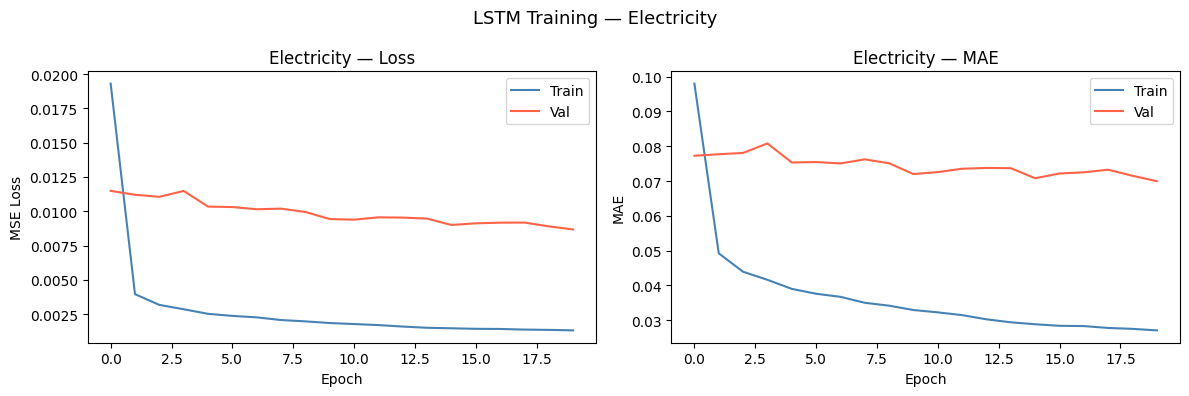


Generating predictions...
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

   Scale verification:
   y_test_actual range : 0.12 to 1.72
   y_pred_actual range : 0.26 to 1.56
   ⚠️ WARNING: Still on log scale!

LSTM — Electricity RESULTS
(RMSE and MAE on actual meter reading scale)
RMSE  : 0.0818
MAE   : 0.0639
R²    : 0.9321
RMSLE : 0.0438
Within 10% : 97.22%
Within 20% : 99.83%
Within 30% : 100.00%


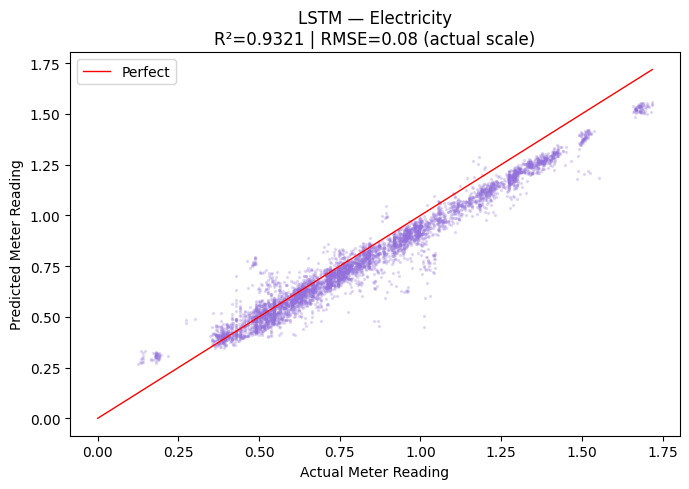


✅ Electricity LSTM saved!


In [ ]:
metrics_elec = train_lstm(
    df,
    meter_id      = 0,
    meter_name    = 'Electricity',
    window        = 24,
    epochs        = 20,
    batch_size    = 512,
    max_buildings = 80
)


LSTM — CHILLED WATER
Selecting buildings...
   Selected 80 buildings across 10 building types
Total rows : 692,954
Buildings  : 80
Types      : 10 building types
Creating stratified sequences...

Train sequences : 29,680
Test sequences  : 12,769
RAM for sequences: 0.06 GB
✅ RAM freed after dataset creation!


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 24, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,249 (489.25 KB)

 Trainable params: 125,249 (489.25 KB)

 Non-trainable params: 0 (0.00 B)


Training...
Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0367 - mae: 0.1338 - val_loss: 0.0036 - val_mae: 0.0384 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0079 - mae: 0.0643 - val_loss: 0.0029 - val_mae: 0.0312 - learning_rate: 0.0010
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0071 - mae: 0.0605 - val_loss: 0.0029 - val_mae: 0.0323 - learning_rate: 0.0010
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0066 - mae: 0.0577 - val_loss: 0.0036 - val_mae: 0.0422 - learning_rate: 0.0010
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0063 - mae: 0.0556 - val_loss: 0.0027 - val_mae: 0.0303 - learning_rate: 0.0010
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0060 - mae: 0.0540 - val_loss: 0.0027 - val_mae: 0.0318 - learning_rate: 0.0010
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0058 - mae: 0.0527 - val_loss: 0.0034 - val_mae: 0.0404 - learning_rate: 0.0010


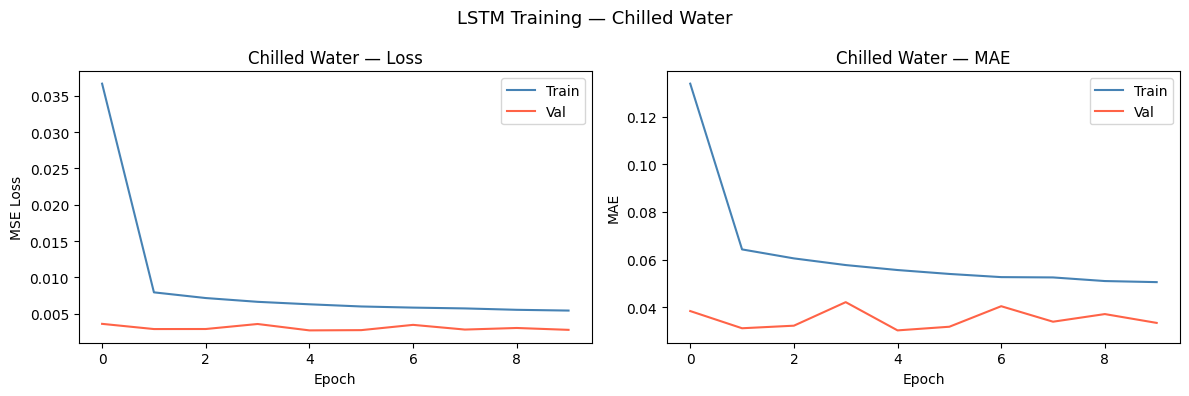


Generating predictions...
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

   Scale verification:
   y_test_actual range : 0.00 to 1.72
   y_pred_actual range : 0.00 to 1.53

LSTM — Chilled Water RESULTS
(Metrics on actual meter reading scale)
RMSE  : 0.1110
MAE   : 0.0749
R²    : 0.9253
RMSLE : 0.0660
Within 10% : 92.30%
Within 20% : 97.97%
Within 30% : 99.37%


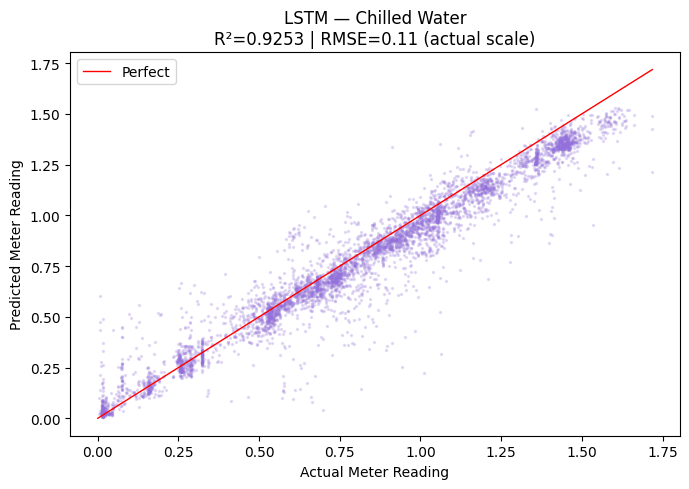


✅ Chilled Water LSTM saved!


In [ ]:
metrics_chw = train_lstm(
    df,
    meter_id      = 1,
    meter_name    = 'Chilled Water',
    window        = 24,
    epochs        = 20,
    batch_size    = 512,
    max_buildings = 80
)


LSTM — STEAM
Selecting buildings...
   Selected 80 buildings across 10 building types
Total rows : 649,589
Buildings  : 80
Types      : 10 building types
Creating stratified sequences...

Train sequences : 37,008
Test sequences  : 15,895
RAM for sequences: 0.07 GB
✅ RAM freed after dataset creation!


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 24, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,249 (489.25 KB)

 Trainable params: 125,249 (489.25 KB)

 Non-trainable params: 0 (0.00 B)


Training...
Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0468 - mae: 0.1445 - val_loss: 0.0047 - val_mae: 0.0536 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0072 - mae: 0.0635 - val_loss: 0.0031 - val_mae: 0.0471 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0057 - mae: 0.0556 - val_loss: 0.0019 - val_mae: 0.0325 - learning_rate: 0.0010
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0051 - mae: 0.0513 - val_loss: 0.0023 - val_mae: 0.0378 - learning_rate: 0.0010
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0047 - mae: 0.0484 - val_loss: 0.0023 - val_mae: 0.0381 - learning_rate: 0.0010
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0048 - mae: 0.0489
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0042 - mae: 0.0455 - val_loss: 0.0021 - val_mae: 0.0354 - learning_rate: 0.0

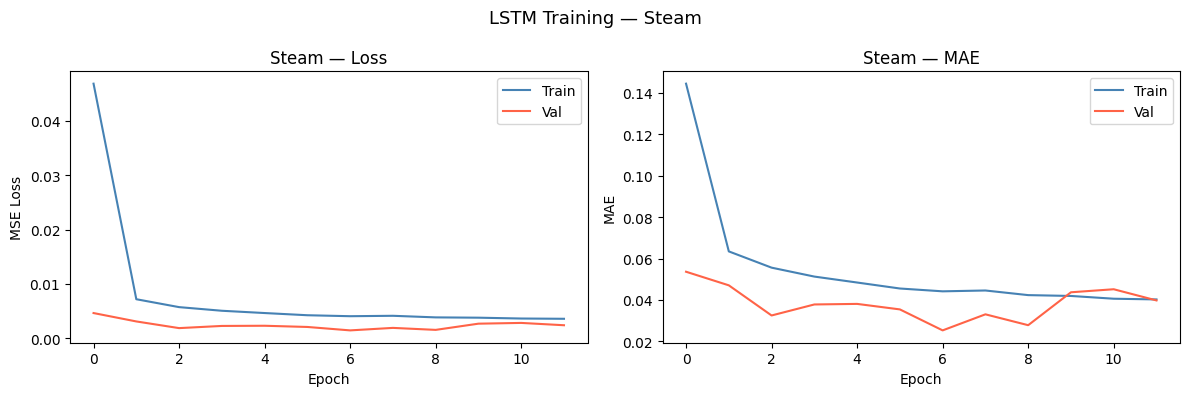


Generating predictions...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

   Scale verification:
   y_test_actual range : 0.00 to 1.72
   y_pred_actual range : 0.03 to 1.70

LSTM — Steam RESULTS
(Metrics on actual meter reading scale)
RMSE  : 0.0822
MAE   : 0.0547
R²    : 0.9407
RMSLE : 0.0431
Within 10% : 97.35%
Within 20% : 99.33%
Within 30% : 99.71%


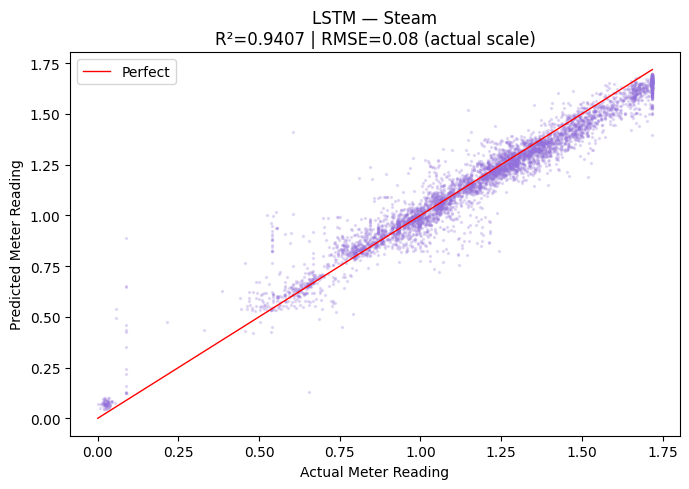


✅ Steam LSTM saved!


In [ ]:
metrics_steam = train_lstm(
    df,
    meter_id      = 2,
    meter_name    = 'Steam',
    window        = 24,
    epochs        = 20,
    batch_size    = 512,
    max_buildings = 80
)


LSTM — HOT WATER
Selecting buildings...
   Selected 59 buildings across 7 building types
Total rows : 511,061
Buildings  : 59
Types      : 7 building types
Creating stratified sequences...

Train sequences : 28,190
Test sequences  : 12,118
RAM for sequences: 0.05 GB
✅ RAM freed after dataset creation!


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 24, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,249 (489.25 KB)

 Trainable params: 125,249 (489.25 KB)

 Non-trainable params: 0 (0.00 B)


Training...
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0477 - mae: 0.1497 - val_loss: 0.0093 - val_mae: 0.0663 - learning_rate: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0142 - mae: 0.0848 - val_loss: 0.0076 - val_mae: 0.0670 - learning_rate: 0.0010
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0126 - mae: 0.0782 - val_loss: 0.0070 - val_mae: 0.0611 - learning_rate: 0.0010
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0117 - mae: 0.0738 - val_loss: 0.0070 - val_mae: 0.0622 - learning_rate: 0.0010
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0114 - mae: 0.0724 - val_loss: 0.0068 - val_mae: 0.0599 - learning_rate: 0.0010
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0113 - mae: 0.0721 - val_loss: 0.0083 - val_mae: 0.0740 - learning_rate: 0.0010
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0109 - mae: 0.0694 - val_loss: 0.0079 - val_mae: 0.0704 - learning_rate: 0.0010


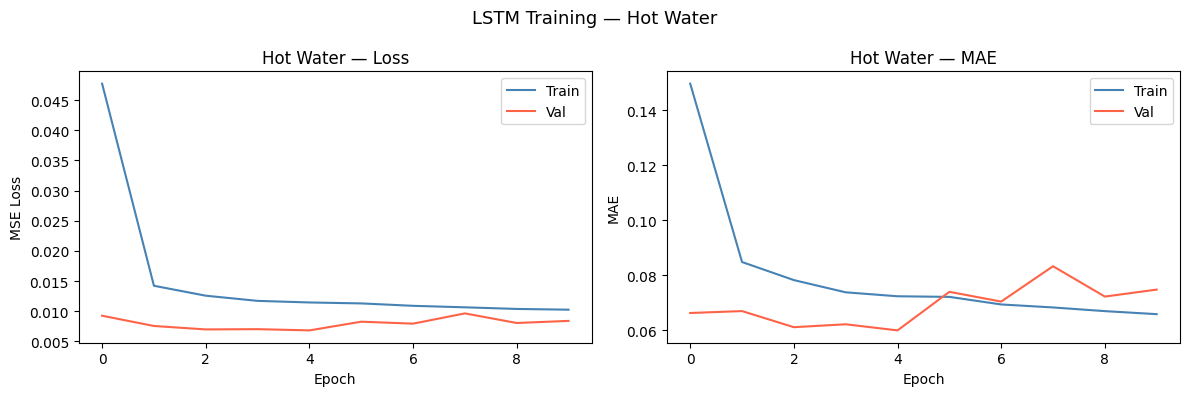


Generating predictions...
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

   Scale verification:
   y_test_actual range : 0.01 to 1.72
   y_pred_actual range : 0.00 to 1.66

LSTM — Hot Water RESULTS
(Metrics on actual meter reading scale)
RMSE  : 0.1610
MAE   : 0.1042
R²    : 0.8183
RMSLE : 0.0907
Within 10% : 86.78%
Within 20% : 95.41%
Within 30% : 98.22%


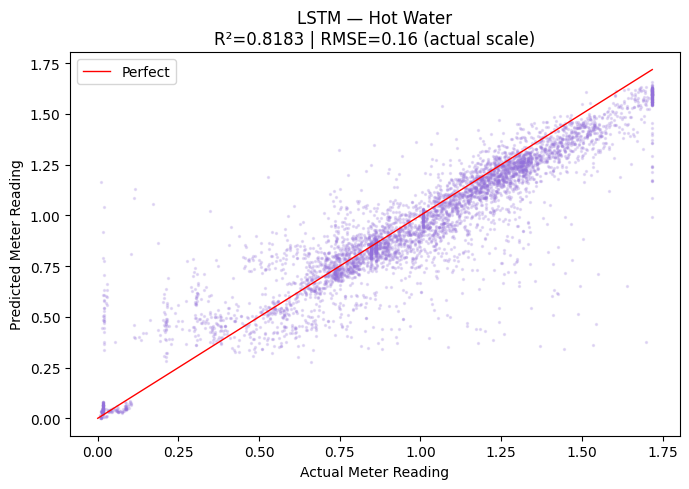


✅ Hot Water LSTM saved!


In [ ]:
metrics_hw = train_lstm(
    df,
    meter_id      = 3,
    meter_name    = 'Hot Water',
    window        = 24,
    epochs        = 20,
    batch_size    = 512,
    max_buildings = 59
)

LSTM v5 — FINAL COMPARISON
RMSE and MAE : actual meter reading scale
RMSLE        : log scale
        Meter   RMSE    MAE     R²  RMSLE
  Electricity 0.0818 0.0639 0.9321 0.0438
Chilled Water 0.1110 0.0749 0.9253 0.0660
        Steam 0.0822 0.0547 0.9407 0.0431
    Hot Water 0.1610 0.1042 0.8183 0.0907


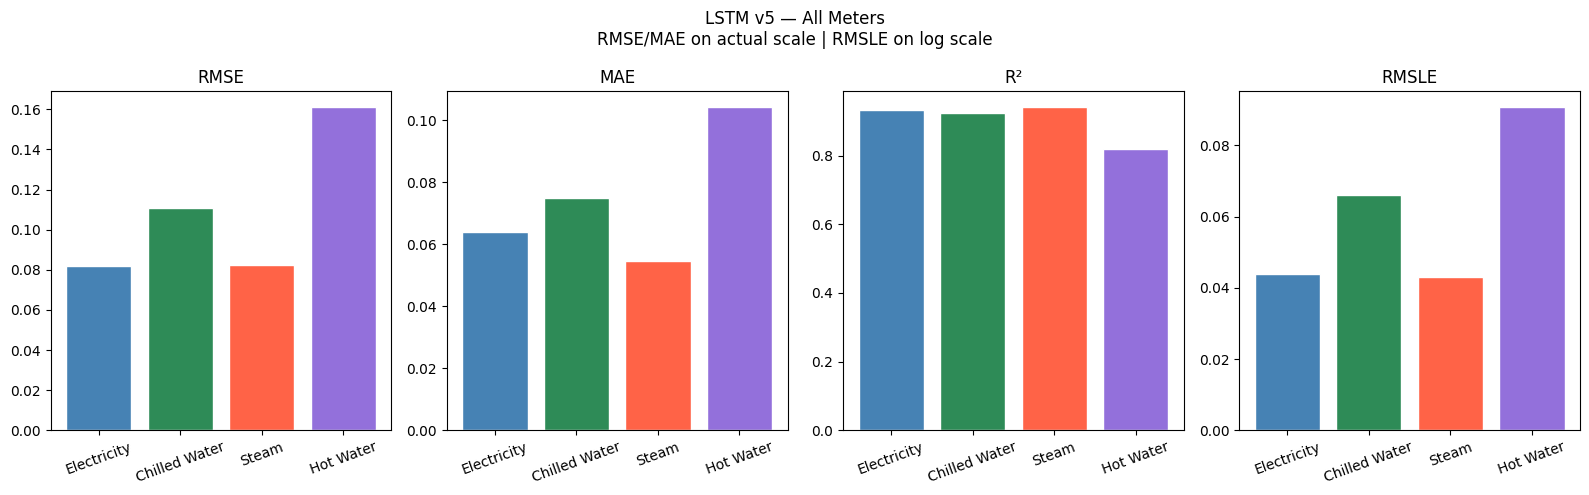

In [ ]:
lstm_results = {}
for name, metrics in [
    ('Electricity',   metrics_elec),
    ('Chilled Water', metrics_chw),
    ('Steam',         metrics_steam),
    ('Hot Water',     metrics_hw)
]:
    if metrics:
        lstm_results[name] = metrics

summary = []
for meter_name, metrics in lstm_results.items():
    summary.append({
        'Meter' : meter_name,
        'RMSE'  : round(metrics[0], 4),
        'MAE'   : round(metrics[1], 4),
        'R²'    : round(metrics[2], 4),
        'RMSLE' : round(metrics[3], 4)
    })

summary_df = pd.DataFrame(summary)

print("=" * 60)
print("LSTM v5 — FINAL COMPARISON")
print("RMSE and MAE : actual meter reading scale")
print("RMSLE        : log scale")
print("=" * 60)
print(summary_df.to_string(index=False))

# Bar charts
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors    = ['steelblue', 'seagreen',
             'tomato', 'mediumpurple']

for i, metric in enumerate(['RMSE', 'MAE', 'R²', 'RMSLE']):
    axes[i].bar(
        summary_df['Meter'],
        summary_df[metric],
        color=colors[:len(summary_df)],
        edgecolor='white'
    )
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle(
    'LSTM v5 — All Meters\n'
    'RMSE/MAE on actual scale | RMSLE on log scale',
    fontsize=12
)
plt.tight_layout()
plt.show()